# Quantum Speedup for Non-Reversible Markov Chains
### Implementation and Complexity Analysis via GQSVT

This notebook provides a self-contained implementation of the quantum algorithm proposed in  
[*Quantum speedup for nonreversible Markov chains* — Claudon, Piquemal & Monmarché, *Nature Communications* 2025](https://doi.org/10.1038/s41467-025-56171-0).

The algorithm prepares the stationary distribution $|\pi\rangle$ of a **non-reversible** ergodic Markov chain using Generalized Quantum Singular Value Transform (GQSVT), achieving a quadratic speedup over classical mixing.

---

**Outline**

1. [Markov Chain Definition](#1-markov-chain-definition)  
2. [Main Operators](#2-main-operators)  
3. [Curved Discriminant & Spectral Gap](#3-curved-discriminant--spectral-gap)  
4. [Chebyshev Fast-Forwarding Polynomial](#4-chebyshev-fast-forwarding-polynomial)  
5. [Quantum Circuit (GQSVT)](#5-quantum-circuit-gqsvt)  
6. [Simulation & Results](#6-simulation--results)  
7. [Complexity: Classical vs. Quantum](#7-complexity-classical-vs-quantum)  
8. [Noise Analysis](#8-noise-analysis)

## 0 · Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from numpy.polynomial import Chebyshev, Polynomial
from scipy.linalg import null_space, block_diag
from scipy.optimize import minimize
from scipy.signal import fftconvolve

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Matplotlib style 
plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "font.size":         11,
})

PALETTE = ["#4c72b0", "#dd8452", "#55a868", "#c44e52",
           "#8172b2", "#937860", "#da8bc3", "#8c8c8c"]

---
## 1 · Markov Chain Definition

We use an $8 \times 8$ non-reversible ergodic Markov kernel $P$ that is deliberately constructed  
to have a **very small pseudo-spectral gap** $\gamma_\infty(P) \approx 10^{-3}$.  
This makes the mixing time classically slow and allows the quantum speedup to manifest clearly.

The state space has two weakly coupled blocks (states $0$–$3$ and $4$–$7$), with cross-block  
transition probabilities of order $10^{-4}$, giving the chain a near-reducible structure  
that is the main source of the small gap.

> **Reproducibility note.** The kernel below is hard-coded and fully deterministic;  
> no random seed is needed.

In [ ]:
# Markov kernel 
DIM = 8  # must be a power of 2

P_raw = np.array([
    [0.54989,      0.34993,      0.079984,     0.019996,
     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.04999,      0.59988,      0.29994,      0.04999,
     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.019996,     0.079984,     0.54989,      0.34993,
     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.29994,      0.04999,      0.04999,      0.59988,
     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.0001731153, 0.0002175774, 0.0001991756, 0.0002101316,
     0.4996,       0.09992,      0.34972,      0.04996],
    [0.0001731153, 0.0002175774, 0.0001991756, 0.0002101316,
     0.29976,      0.4996,       0.04996,      0.14988],
    [0.0001731153, 0.0002175774, 0.0001991756, 0.0002101316,
     0.04996,      0.34972,      0.4996,       0.09992],
    [0.0001731153, 0.0002175774, 0.0001991756, 0.0002101316,
     0.09992,      0.04996,      0.29976,      0.54956],
], dtype=float)

# Renormalise rows to correct floating-point rounding in the literal above
P = P_raw / P_raw.sum(axis=1, keepdims=True)

assert P.shape == (DIM, DIM), "P must be square with side DIM"
assert np.allclose(P.sum(axis=1), 1.0), "Rows must sum to 1"
assert np.all(P >= 0), "All entries must be non-negative"
print("✓ Markov kernel loaded — shape:", P.shape)

✓ Markov kernel loaded — shape: (8, 8)


### 1.1 · Stationary distribution

The stationary distribution $\pi$ satisfies $\pi P = \pi$ and is found as the  
left eigenvector of $P^\top$ associated with eigenvalue $1$.

In [ ]:
# Stationary distribution 
eigvals, eigvecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigvals - 1.0))
pi = np.real(eigvecs[:, idx])
if pi.sum() < 0:
    pi = -pi
pi = np.maximum(pi, 0.0)
pi /= pi.sum()

pi_state = np.sqrt(pi).reshape(-1, 1)   # coherent stationary state |π⟩

print("Stationary distribution π:")
for i, p in enumerate(pi):
    print(f"  π({i}) = {p:.6f}")
print(f"\nSum = {pi.sum():.10f}  (should be 1)")

Stationary distribution π:
  π(0) = 0.173115
  π(1) = 0.217577
  π(2) = 0.199176
  π(3) = 0.210132
  π(4) = 0.046778
  π(5) = 0.055481
  π(6) = 0.060586
  π(7) = 0.037155

Sum = 1.0000000000  (should be 1)


### 1.2 · Non-reversibility check

A chain is reversible iff it satisfies **detailed balance**: $\pi(x)P(x,y) = \pi(y)P(y,x)$ for all $x,y$.  
We verify that this is violated, confirming the chain is non-reversible.

In [ ]:
# Non-reversibility check 
max_violation = np.max(np.abs(
    np.outer(pi, np.ones(DIM)) * P - np.outer(np.ones(DIM), pi) * P.T
))
assert max_violation > 1e-6, "Detailed balance holds — chain appears reversible!"
print(f"✓ Non-reversible  (max detailed-balance violation = {max_violation:.2e})")

✓ Non-reversible  (max detailed-balance violation = 5.96e-02)


### 1.3 · Time-reversal kernel

The **adjoint** (time-reversal) kernel $P^\star$ with respect to $\pi$ is defined by  
$$P^\star(x, y) = \frac{\pi(y)}{\pi(x)} P(y, x).$$

In [ ]:
# Time-reversal kernel P* 
P_rev = (np.outer(pi, np.ones(DIM)) ** (-1)) * np.outer(np.ones(DIM), pi) * P.T

# Equivalently: P_rev[i, j] = (pi[j] / pi[i]) * P[j, i]
P_rev = np.maximum(P_rev, 0.0)
P_rev /= P_rev.sum(axis=1, keepdims=True)

assert np.allclose(P_rev.sum(axis=1), 1.0), "P_rev must be row-stochastic"
print("✓ Time-reversal kernel P* computed")

✓ Time-reversal kernel P* computed


---
## 2 · Main Operators

To encode the Markov chain in a quantum circuit we need three matrix-level objects.

**Partial isometries** — state-preparation maps satisfying $\square^\dagger \square = I$:
$$\square_P = \sum_{x,y \in S} \sqrt{P(x,y)}\,|x\rangle|y\rangle\langle x|, 
\qquad
\square_{P^\star} = \sum_{x,y \in S} \sqrt{P^\star(x,y)}\,|x\rangle|y\rangle\langle x|.$$

**Swap operator**:
$$S = \sum_{x,y \in S} |x,y\rangle\langle y,x|.$$

**Hermitised walk operator** (for GQSVT on the curved discriminant):
$$\widehat{\square} = |0\rangle\langle 0|\otimes\square_{P^\star} + |1\rangle\langle 1|\otimes\square_P,
\qquad
\widehat{S} = \bigl(|0\rangle\langle 0|\otimes S + |1\rangle\langle 1|\otimes S\bigr)(X\otimes I),$$
$$W = \bigl(2\widehat{\square}\widehat{\square}^\dagger - I\bigr)\widehat{S}.$$

In [ ]:
# Basis vectors 
eye   = np.eye(DIM)
basis = [eye[:, i:i+1] for i in range(DIM)]   # list of column vectors

# Partial isometries 
square     = sum(np.sqrt(P[x, y])     * np.kron(basis[x], basis[y]) @ basis[x].T
                 for x in range(DIM) for y in range(DIM))
square_rev = sum(np.sqrt(P_rev[x, y]) * np.kron(basis[x], basis[y]) @ basis[x].T
                 for x in range(DIM) for y in range(DIM))

assert np.allclose(square_rev.T @ square_rev, np.eye(DIM)), "square_rev must be an isometry"
assert np.allclose(square.T     @ square,     np.eye(DIM)), "square must be an isometry"

# Swap operator 
swap = sum(np.kron(basis[x], basis[y]) @ np.kron(basis[y].T, basis[x].T)
           for x in range(DIM) for y in range(DIM))

# Hermitised operators 
proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
X_gate = np.array([[0, 1], [1, 0]], dtype=complex)

square_herm = np.kron(proj_0, square_rev) + np.kron(proj_1, square)
swap_herm   = (np.kron(proj_0, swap) + np.kron(proj_1, swap)) @ np.kron(X_gate, np.eye(DIM**2, dtype=complex))

# Hermitised walk operator W 
I_large = np.eye(2 * DIM**2)
W_herm  = (2 * square_herm @ square_herm.conj().T - I_large) @ swap_herm

assert np.allclose(W_herm @ W_herm.conj().T, I_large, atol=1e-10), "W must be unitary"
print("✓ Walk operator W constructed and verified unitary")

✓ Walk operator W constructed and verified unitary


---
## 3 · Curved Discriminant & Spectral Gap

The **curved discriminant** $D = \square_{P^\star}^\dagger S\, \square_P$ encodes the chain's  
spectral structure. Its entries are $D(x,y) = \sqrt{P^\star(x,y)\,P(y,x)}$.

Key properties (proved in the paper):
- $D$ is similar to $P$ and therefore shares its spectrum.  
- The **leading singular value** of $D$ is $\sigma_1 = 1$, with left and right  
  singular vectors both equal to $|\pi\rangle = \sum_x \sqrt{\pi(x)}|x\rangle$.  
- The **spectral gap** $\delta = 1 - \sigma_2$ governs the polynomial degree needed:  
  $d = O\!\left(\delta^{-1/2}\log(1/\varepsilon)\right)$, giving the quadratic speedup over  
  the classical $O(\delta^{-1}\log(1/\varepsilon))$.

In [ ]:
# Curved discriminant
D = square_rev.T @ swap @ square

# Element-wise sanity check
D_check = np.array([[np.sqrt(P_rev[x, y] * P[y, x]) for y in range(DIM)] for x in range(DIM)])
assert np.allclose(D, D_check, atol=1e-12), "Curved discriminant definition mismatch"

# SVD
U_svd, svalues, Vt_svd = np.linalg.svd(D)
spectral_gap = 1.0 - svalues[1]

assert np.isclose(svalues[0], 1.0, atol=1e-10), "Leading singular value must be 1"

# Check that leading singular vectors match |π⟩
left_vec  = U_svd[:, 0]  * np.sign(np.real(U_svd[0, 0]))
right_vec = Vt_svd[0, :].conj() * np.sign(np.real(Vt_svd[0, 0]))

assert np.allclose(np.abs(left_vec),  np.abs(pi_state.flatten()), atol=1e-8)
assert np.allclose(np.abs(right_vec), np.abs(pi_state.flatten()), atol=1e-8)

print("✓ Curved discriminant verified")
print(f"  Singular values : {np.round(svalues, 6)}")
print(f"  Spectral gap  δ : {spectral_gap:.6f}  (σ₂ = {svalues[1]:.6f})")

✓ Curved discriminant verified
  Singular values : [1.       0.999    0.61798  0.570016 0.485869 0.382831 0.368726 0.249014]
  Spectral gap  δ : 0.001000  (σ₂ = 0.999000)


---
## 4 · Chebyshev Fast-Forwarding Polynomial

We apply the polynomial
$$\nu(x) = \varepsilon\, T_d\!\left(\alpha x\right), 
\quad \alpha = \cosh\!\left(\frac{\operatorname{arccosh}(1/\varepsilon)}{d}\right),$$
to the singular values of $D$.  By construction $\nu(\sigma_1) = \nu(1) = 1$, and  
$|\nu(x)| \le \varepsilon$ for all other singular values, so $\nu(D) \approx |\pi\rangle\langle\pi|$.

The minimum degree is
$$d = \left\lceil \frac{\operatorname{arccosh}(1/\varepsilon)}{\operatorname{arccosh}\!\left(1/(1-\delta)\right)} \right\rceil$$
rounded up to the nearest even integer (GQSVT requires an even polynomial).

In [ ]:
# Polynomial parameters 
EPSILON = 0.001   # target suppression of non-leading singular values

d_raw = np.arccosh(1.0 / EPSILON) / np.arccosh(1.0 / (1.0 - spectral_gap))
d     = int(np.ceil(d_raw))
if d % 2 != 0:
    d += 1          # GQSVT requires an even polynomial

alpha = np.cosh(np.arccosh(1.0 / EPSILON) / d)

print(f"ε         = {EPSILON}")
print(f"d (raw)   = {d_raw:.3f}")
print(f"d (used)  = {d}")
print(f"α         = {alpha:.8f}")

ε         = 0.001
d (raw)   = 169.891
d (used)  = 170
α         = 1.00099971


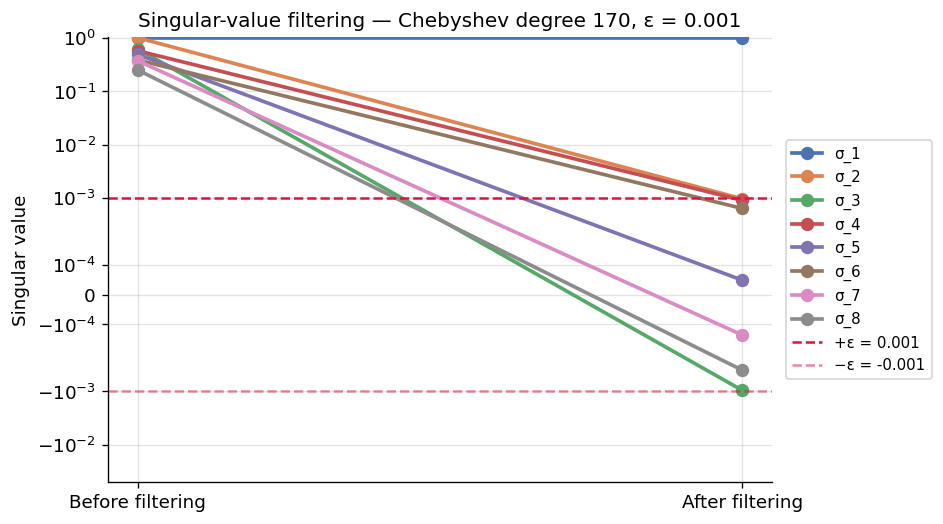

✓ Leading singular value after filtering: 1.000000  (target 1.0)


In [ ]:
# Build ν in the Chebyshev basis 
x_poly   = Polynomial([0.0, alpha])           # the map x ↦ αx
nu_power = EPSILON * Chebyshev.basis(d)(x_poly)  # ε · T_d(αx)
nu       = nu_power.convert(kind=Chebyshev)
P_coefficients = np.array(nu.coef)

# Visualise spectral filtering 
cheb_coeffs  = [0.0] * d + [1.0]
nu_at_svals  = EPSILON * np.polynomial.chebyshev.chebval(alpha * svalues, cheb_coeffs)

fig, ax = plt.subplots(figsize=(8, 4.5))
x_ticks = ["Before filtering", "After filtering"]

for i in range(DIM):
    ax.plot(x_ticks, [svalues[i], nu_at_svals[i]],
            marker="o", markersize=7, color=PALETTE[i],
            linewidth=2.2, label=f"σ_{i+1}")

ax.axhline( EPSILON, color="crimson", ls="--", lw=1.5, label=f"+ε = {EPSILON}")
ax.axhline(-EPSILON, color="crimson", ls="--", lw=1.5, alpha=0.5, label=f"−ε = {-EPSILON}")
ax.set_yscale("symlog", linthresh=EPSILON / 5)
ax.set_title(f"Singular-value filtering — Chebyshev degree {d}, ε = {EPSILON}", fontsize=12)
ax.set_ylabel("Singular value")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.tight_layout()
plt.show()
print(f"✓ Leading singular value after filtering: {nu_at_svals[0]:.6f}  (target 1.0)")

---
## 5 · Quantum Circuit (GQSVT)

We implement
$$\bigl(\langle 01|\otimes\square_P^\dagger\bigr)\,G\,\bigl(|01\rangle\otimes\square_P\bigr)
\;=\; \nu(D) \;\approx\; |\pi\rangle\langle\pi|,$$
where $G$ is the GQSP circuit that applies $\nu$ to the walk operator $W$.

**Qubit registers**

| Register | Size | Role |
|---|---|---|
| `s` | 1 | GQSP signal ancilla |
| `x` | $\log_2 n$ | current state of the chain |
| `y` | $\log_2 n$ | target state (transition register) |
| `h` | 1 | Hermitisation ancilla |

**Post-selection condition** (for a valid sample): `s = 0`, `h = 1`, `y = 00…0`.

### 5.1 · Helper functions

In [ ]:
# Unitary extension of a normalised vector 
def complete_vector_to_unitary(v, atol=1e-12):
    """Return a unitary U whose first column is the normalised vector v."""
    v = np.asarray(v, dtype=complex).reshape(-1, 1)
    assert np.isclose(np.linalg.norm(v), 1.0, atol=atol), "v must be normalised"
    complement = null_space(v.conj().T)
    U = np.hstack([v, complement])
    assert np.allclose(U.conj().T @ U, np.eye(v.shape[0]), atol=atol)
    return U


# Block-diagonal unitary extension of the partial isometry 
def build_controlled_unitary_extension(P, atol=1e-12):
    """
    Build  V = ⊕_x V_x  where  V_x |0⟩ = Σ_y √P[x,y] |y⟩.
    V is a unitary that extends the isometry □_P.
    """
    dim = P.shape[0]
    blocks = [complete_vector_to_unitary(np.sqrt(P[x]).astype(complex)) for x in range(dim)]
    V = block_diag(*blocks)
    assert np.allclose(V.conj().T @ V, np.eye(dim**2), atol=atol), "V must be unitary"
    return V, blocks


# Math-to-Qiskit index permutations 
def permutation_xy(dim):
    """Reorder |x⟩|y⟩ from big-endian (math) to little-endian (Qiskit)."""
    N = dim * dim
    P_mat = np.zeros((N, N), dtype=complex)
    for x in range(dim):
        for y in range(dim):
            P_mat[x + dim * y, dim * x + y] = 1.0
    return P_mat

def permutation_hxy(dim):
    """Reorder |h⟩|x⟩|y⟩ from big-endian (math) to little-endian (Qiskit)."""
    N = 2 * dim * dim
    P_mat = np.zeros((N, N), dtype=complex)
    for h in range(2):
        for x in range(dim):
            for y in range(dim):
                math_idx   = h * dim**2 + dim * x + y
                qiskit_idx = x + dim * y + dim**2 * h
                P_mat[qiskit_idx, math_idx] = 1.0
    return P_mat


# GQSP rotation gate
def rotation_gate(theta, phi, lam):
    """Single-qubit GQSP rotation R(θ, φ, λ) returned as a UnitaryGate."""
    U = np.array([
        [np.exp(1j*(lam + phi)) * np.cos(theta),  np.exp(1j*phi) * np.sin(theta)],
        [np.exp(1j*lam)         * np.sin(theta), -np.cos(theta)],
    ], dtype=complex)
    return UnitaryGate(U, label=r"$R_{\mathrm{GQSP}}$")


# Find complementary polynomial Q, taken from GQSP paper
def find_Q_polynomial(P_coefs):
    """
    Calculates the coefficients of polynomial Q given polynomial P 
    for Generalized Quantum Signal Processing (GQSP).
    
    Args:
        P_coefs (numpy.ndarray): Complex coefficients of P [a_0, a_1, ..., a_d]
        
    Returns:
        numpy.ndarray: Complex coefficients of Q [b_0, b_1, ..., b_d]
    """
    a = np.array(P_coefs, dtype=complex)
    d = len(a) - 1
    
    a_rev_conj = np.conjugate(a[::-1])
    a_conv = fftconvolve(a, a_rev_conj)
    
    delta = np.zeros(2*d + 1, dtype=complex)
    delta[d] = 1.0
    
    target_b_conv = delta - a_conv
    
    def objective(b_concat):

        b = b_concat[:d+1] + 1j * b_concat[d+1:]
        
        # Compute b * reverse(b)*
        b_rev_conj = np.conjugate(b[::-1])
        b_conv = fftconvolve(b, b_rev_conj)
        
        # L2 norm squared of the difference
        diff = b_conv - target_b_conv
        return np.sum(np.abs(diff)**2)

    np.random.seed(42) # Fixed seed for reproducibility 
    b_init = np.random.randn(d+1) + 1j * np.random.randn(d+1)
    
    x0 = np.concatenate([np.real(b_init), np.imag(b_init)])
    
    result = minimize(objective, x0, method='L-BFGS-B', 
                      options={'maxiter': 50000, 'ftol': 1e-12})
    
    if not result.success:
        print(f"Warning: Optimization may not have fully converged. Message: {result.message}")
        print(f"Final objective value: {result.fun}")
        
    b_opt = result.x[:d+1] + 1j * result.x[d+1:]
    
    return b_opt

# Compute GQSP rotation angles, taken from GQSP paper
def compute_rotation_angles(S, d):
    """
    Computes the rotation angles for GQSP.
    
    Args:
        S (numpy.ndarray): 2 x (d+1) complex matrix where the first row 
                           contains the coefficients of P and the second row 
                           contains the coefficients of Q.
        d (int): Degree of the polynomials.
        
    Returns:
        tuple: (theta_list, phi_list, lambda_val)
               where theta_list and phi_list are ordered from index 0 to d.
    """
    theta_list = []
    phi_list = []
    
    # Make a copy to avoid mutating the original input
    current_S = np.array(S, dtype=complex)
    
    # Process from degree d down to 1
    for current_d in range(d, 0, -1):
        a_d = current_S[0][current_d]
        b_d = current_S[1][current_d]
        
        abs_a = np.abs(a_d)
        abs_b = np.abs(b_d)
        
        theta_d = np.arctan2(abs_b, abs_a)
        if abs_b == 0:
            phi_d = np.angle(a_d)
        elif abs_a == 0:
            phi_d = -np.angle(b_d)
        else:
            phi_d = np.angle(a_d * np.conj(b_d))
            
        theta_list.append(theta_d)
        phi_list.append(phi_d)
        
        exp_neg_i_phi = np.exp(-1j * phi_d)
        cos_t = np.cos(theta_d)
        sin_t = np.sin(theta_d)
        
        R_dagger = np.array([
            [exp_neg_i_phi * cos_t,  sin_t],
            [exp_neg_i_phi * sin_t, -cos_t]
        ])
        
        S_temp = R_dagger @ current_S
        
        P_hat = S_temp[0][1:]  
        
        Q_hat = S_temp[1][:-1] 
        
        current_S = np.array([P_hat, Q_hat])
        
    a_0 = current_S[0][0]
    b_0 = current_S[1][0]
    
    abs_a0 = np.abs(a_0)
    abs_b0 = np.abs(b_0)
    
    theta_0 = np.arctan2(abs_b0, abs_a0)
    
    if abs_b0 == 0:
        phi_0 = np.angle(a_0)
        lambda_val = 0.0
    elif abs_a0 == 0:
        phi_0 = -np.angle(b_0)
        lambda_val = np.angle(b_0)
    else:
        phi_0 = np.angle(a_0 * np.conj(b_0))
        lambda_val = np.angle(b_0)
        
    theta_list.append(theta_0)
    phi_list.append(phi_0)
    
    # Reverse the lists because we processed from d down to 0, 
    # but the circuit requires them from 0 up to d.
    theta_list.reverse()
    phi_list.reverse()
    
    return theta_list, phi_list, lambda_val

print("✓ All helper functions defined")

✓ All helper functions defined


### 5.2 · Compute GQSP angles

In [22]:
print("Computing GQSP angles (this may take a minute for d = %d)..." % d)

Q_coefficients = find_Q_polynomial(P_coefficients)
S = np.vstack([P_coefficients, Q_coefficients])
theta_list, phi_list, lambda_val = compute_rotation_angles(S, d)

print(f"✓ Computed {len(theta_list)} rotation angles  (d = {d})")
print(f"  λ = {lambda_val:.6f}")

Computing GQSP angles (this may take a minute for d = 170)...
✓ Computed 171 rotation angles  (d = 170)
  λ = 1.026332


### 5.3 · Build the quantum circuit

✓ Circuit built
  Depth  : 5
  Qubits : 8


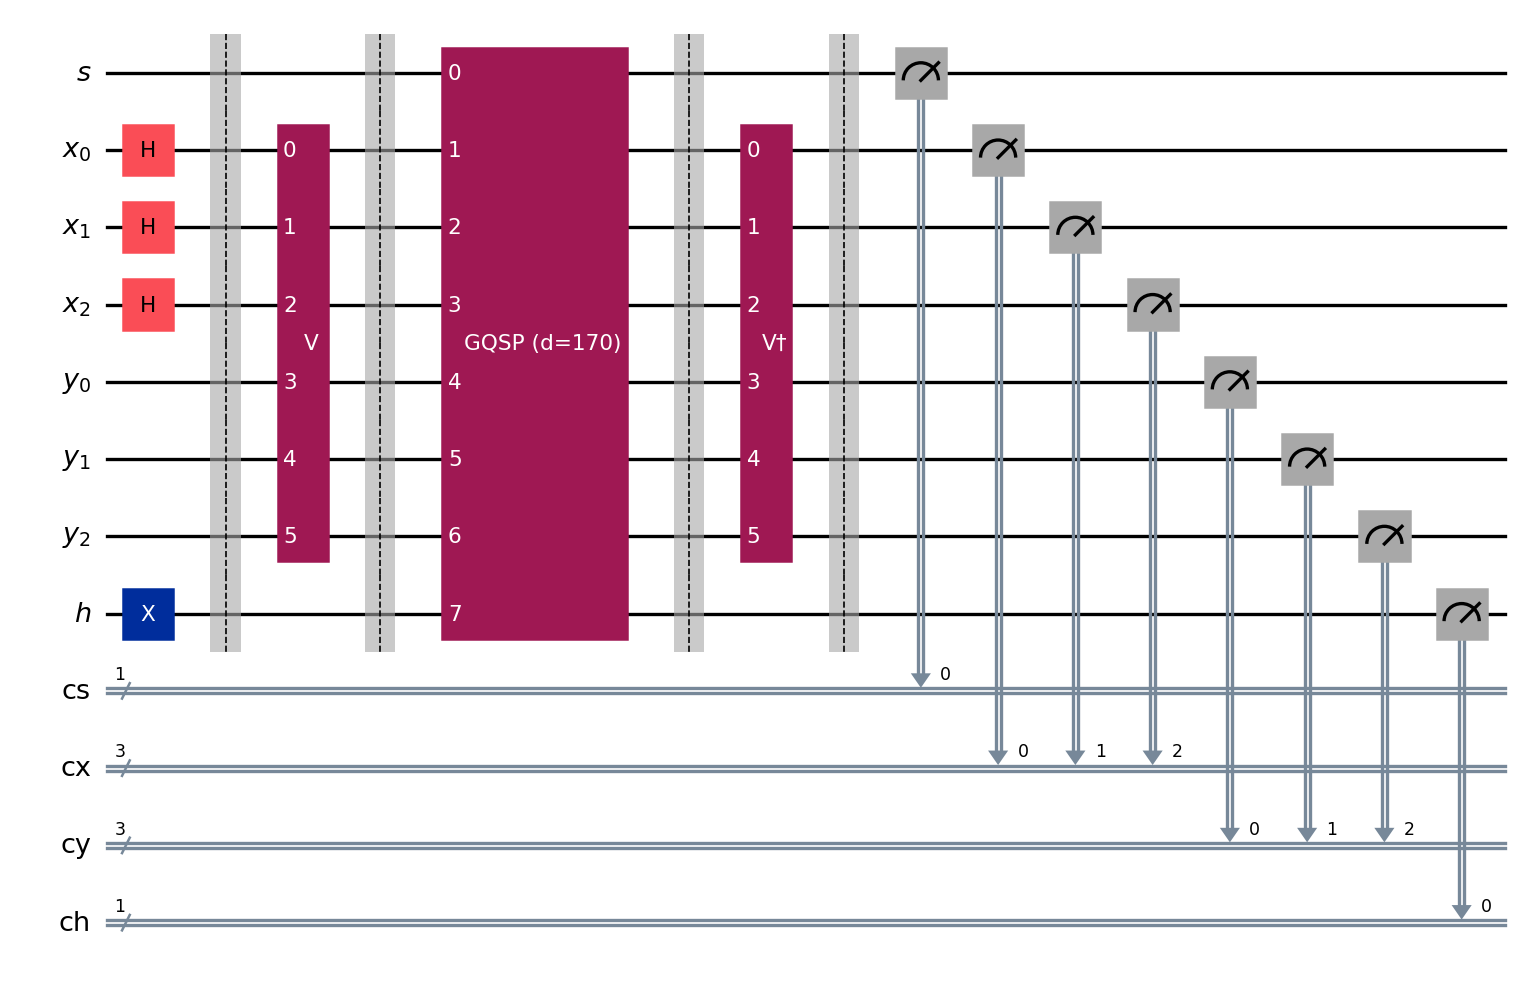

In [ ]:
N_STATE_QUBITS = int(np.log2(DIM))

# Qiskit-ordered unitaries 
perm_xy  = permutation_xy(DIM)
perm_hxy = permutation_hxy(DIM)

V, _     = build_controlled_unitary_extension(P)
V_qiskit = perm_xy  @ V      @ perm_xy.conj().T
W_qiskit = perm_hxy @ W_herm @ perm_hxy.conj().T

assert np.allclose(V_qiskit.conj().T @ V_qiskit, np.eye(DIM**2),    atol=1e-10)
assert np.allclose(W_qiskit.conj().T @ W_qiskit, np.eye(2*DIM**2),  atol=1e-10)

# Qiskit gates 
V_gate  = UnitaryGate(V_qiskit,            label="V")
Vd_gate = UnitaryGate(V_qiskit.conj().T,   label=r"V†")
W_gate  = UnitaryGate(W_qiskit,            label="W")
A_gate  = W_gate.control(num_ctrl_qubits=1, ctrl_state="0")   # controlled-W (on |0⟩)

# ── Quantum registers ─────────────────────────────────────────────────────────
qs = QuantumRegister(1,            "s")
qx = QuantumRegister(N_STATE_QUBITS, "x")
qy = QuantumRegister(N_STATE_QUBITS, "y")
qh = QuantumRegister(1,            "h")
cs = ClassicalRegister(1,            "cs")
cx = ClassicalRegister(N_STATE_QUBITS, "cx")
cy = ClassicalRegister(N_STATE_QUBITS, "cy")
ch = ClassicalRegister(1,            "ch")

qc = QuantumCircuit(qs, qx, qy, qh, cs, cx, cy, ch)

# Initialisation
for q in qx:              # equal superposition over x-register
    qc.h(q)
qc.x(qh[0])              # h qubit → |1⟩  (selects the □_P block)
qc.barrier()

# Apply V 
qc.append(V_gate, list(qx) + list(qy))
qc.barrier()

# GQSP block
gqsp_sub = QuantumCircuit(qs, qx, qy, qh, name=f"GQSP (d={d})")
for j, theta_j in enumerate(theta_list):
    phi_j = phi_list[j]
    if j > 0:
        gqsp_sub.append(A_gate, list(qs) + list(qx) + list(qy) + list(qh))
    lam_j = lambda_val if j == 0 else 0.0
    gqsp_sub.append(rotation_gate(theta_j, phi_j, lam_j), qs)

qc.append(gqsp_sub.to_instruction(), list(qs) + list(qx) + list(qy) + list(qh))
qc.barrier()

# Apply V† 
qc.append(Vd_gate, list(qx) + list(qy))
qc.barrier()

# Measurements 
qc.measure(qs, cs); qc.measure(qx, cx); qc.measure(qy, cy); qc.measure(qh, ch)

print("✓ Circuit built")
print(f"  Depth  : {qc.depth()}")
print(f"  Qubits : {qc.num_qubits}")
qc.draw("mpl", fold=60)

---
## 6 · Simulation & Results

We run the circuit on a **noiseless** Qiskit Aer simulator and post-select on  
`s = 0`, `h = 1`, `y = 00…0` to recover the empirical distribution $\tilde{\pi}$.  
The quality is measured by the Total Variation Distance  
$$d_{\mathrm{TV}}(\tilde{\pi},\pi) = \tfrac{1}{2}\sum_x |\tilde{\pi}(x) - \pi(x)|.$$

In [ ]:
SHOTS = 100000
ZERO_Y = "0" * N_STATE_QUBITS

simulator = AerSimulator()
job = simulator.run(transpile(qc, simulator), shots=SHOTS)
raw_counts = job.result().get_counts()

# Post-selection 
post_counts = {}
n_success   = 0

for bitstring, count in raw_counts.items():
    ch_val, cy_val, cx_val, cs_val = bitstring.split()
    if cs_val == "0" and ch_val == "1" and cy_val == ZERO_Y:
        post_counts[cx_val] = post_counts.get(cx_val, 0) + count
        n_success += count

success_rate = n_success / SHOTS
probabilities = {k: v / n_success for k, v in post_counts.items()}

measured = np.zeros(DIM)
for cx_bs, prob in probabilities.items():
    measured[int(cx_bs, 2)] += prob

tvd = 0.5 * np.sum(np.abs(pi - measured))

print(f"Post-selection success rate : {success_rate*100:.2f}%")
print(f"TVD(π̃, π)                  : {tvd:.5f}")
print()
print(f"{'State':>6}  {'π̃ (measured)':>14}  {'π (theory)':>12}  {'|Δ|':>8}")
print("-" * 46)
for i in range(DIM):
    print(f"  |{i}⟩   {measured[i]:14.6f}  {pi[i]:12.6f}  {abs(measured[i]-pi[i]):8.6f}")

Post-selection success rate : 72.06%
TVD(π̃, π)                  : 0.10583

 State   π̃ (measured)    π (theory)       |Δ|
----------------------------------------------
  |0⟩         0.183800      0.173115  0.010685
  |1⟩         0.257029      0.217577  0.039451
  |2⟩         0.228747      0.199176  0.029572
  |3⟩         0.236255      0.210132  0.026123
  |4⟩         0.032319      0.046778  0.014459
  |5⟩         0.025381      0.055481  0.030100
  |6⟩         0.018540      0.060586  0.042046
  |7⟩         0.017929      0.037155  0.019226


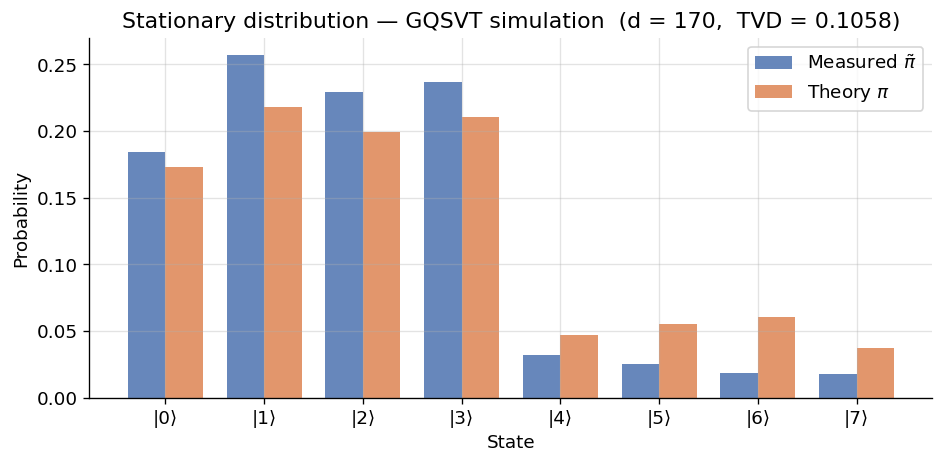

In [ ]:
# Bar chart comparison 
states = np.arange(DIM)
width  = 0.38

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(states - width/2, measured, width, label="Measured $\\tilde{\\pi}$",
       color=PALETTE[0], alpha=0.85)
ax.bar(states + width/2, pi,       width, label="Theory $\\pi$",
       color=PALETTE[1], alpha=0.85)
ax.set_xticks(states, [f"|{i}⟩" for i in states])
ax.set_xlabel("State"); ax.set_ylabel("Probability")
ax.set_title(f"Stationary distribution — GQSVT simulation  (d = {d},  TVD = {tvd:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

---
## 7 · Complexity: Classical vs. Quantum

We compare the number of **oracle calls** (matrix–vector products for classical,  
polynomial degree for quantum) needed to reach a given TVD from stationarity.

For each degree $d$ in the range $[42, 170]$ (corresponding to $\varepsilon \in [0.3, 0.001]$):
- **Classical**: run $d$ steps of the chain from state $|0\rangle$.  
- **Quantum**: run the GQSVT circuit with the Chebyshev polynomial of degree $d$.

In [ ]:
# Self-contained runner (no side-effects on outer variables) 
def run_nonreversible(P, epsilon, simulator=None, degree=None, shots=100_000):
    """
    Build and simulate the GQSVT circuit for a non-reversible kernel P.

    Parameters
    ----------
    P        : (n, n) row-stochastic numpy array  (n must be a power of 2)
    epsilon  : target suppression ε for the Chebyshev polynomial
    simulator: Qiskit Aer simulator instance  (default: noiseless AerSimulator)
    degree   : override the polynomial degree  (default: compute from ε and δ)
    shots    : number of circuit shots

    Returns
    -------
    tvd : Total Variation Distance between the measured and true stationary distributions
    """
    if simulator is None:
        simulator = AerSimulator()

    dim = P.shape[0]
    n_q = int(np.log2(dim))
    assert 2**n_q == dim

    P = np.maximum(P, 0.0); P /= P.sum(axis=1, keepdims=True)

    # Stationary distribution
    evals, evecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(evals - 1.0))
    pi_ = np.real(evecs[:, idx]); pi_ = np.maximum(pi_ * np.sign(pi_.sum()), 0.0); pi_ /= pi_.sum()

    # Time reversal
    P_r = np.maximum((np.outer(np.ones(dim), pi_) / np.outer(pi_, np.ones(dim))) * P.T, 0.0)
    P_r /= P_r.sum(axis=1, keepdims=True)

    # Basis
    eye_  = np.eye(dim)
    bas_  = [eye_[:, i:i+1] for i in range(dim)]

    sq_   = sum(np.sqrt(P[x,y])   * np.kron(bas_[x], bas_[y]) @ bas_[x].T for x in range(dim) for y in range(dim))
    sqr_  = sum(np.sqrt(P_r[x,y]) * np.kron(bas_[x], bas_[y]) @ bas_[x].T for x in range(dim) for y in range(dim))
    swp_  = sum(np.kron(bas_[x], bas_[y]) @ np.kron(bas_[y].T, bas_[x].T) for x in range(dim) for y in range(dim))

    p0_, p1_ = np.array([[1,0],[0,0]], dtype=complex), np.array([[0,0],[0,1]], dtype=complex)
    Xg_ = np.array([[0,1],[1,0]], dtype=complex)
    sq_h = np.kron(p0_, sqr_) + np.kron(p1_, sq_)
    sw_h = (np.kron(p0_, swp_) + np.kron(p1_, swp_)) @ np.kron(Xg_, np.eye(dim**2, dtype=complex))
    W_   = (2 * sq_h @ sq_h.conj().T - np.eye(2*dim**2)) @ sw_h

    D_   = sqr_.T @ swp_ @ sq_
    _, sv_, _ = np.linalg.svd(D_)
    delta_ = 1.0 - sv_[1]

    if degree is None:
        d_ = int(np.ceil(np.arccosh(1/epsilon) / np.arccosh(1/(1-delta_))))
        if d_ % 2 != 0: d_ += 1
    else:
        d_ = degree

    alpha_ = np.cosh(np.arccosh(1/epsilon) / d_)
    xp_    = Polynomial([0.0, alpha_])
    nu_    = (epsilon * Chebyshev.basis(d_)(xp_)).convert(kind=Chebyshev)
    Pc_    = np.array(nu_.coef)
    Qc_    = find_Q_polynomial(Pc_)
    S_ = np.vstack([Pc_, Qc_])
    th_, ph_, lv_ = compute_rotation_angles(S_, d_)

    V_, _   = build_controlled_unitary_extension(P)
    pxy_    = permutation_xy(dim); phxy_ = permutation_hxy(dim)
    Vq_     = pxy_  @ V_  @ pxy_.conj().T
    Wq_     = phxy_ @ W_  @ phxy_.conj().T

    Vg_  = UnitaryGate(Vq_,          label="V")
    Vdg_ = UnitaryGate(Vq_.conj().T, label="V†")
    Wg_  = UnitaryGate(Wq_,          label="W")
    Ag_  = Wg_.control(num_ctrl_qubits=1, ctrl_state="0")

    qs_=QuantumRegister(1,"s"); qx_=QuantumRegister(n_q,"x")
    qy_=QuantumRegister(n_q,"y"); qh_=QuantumRegister(1,"h")
    cs_=ClassicalRegister(1,"cs"); cx_=ClassicalRegister(n_q,"cx")
    cy_=ClassicalRegister(n_q,"cy"); ch_=ClassicalRegister(1,"ch")
    qc_=QuantumCircuit(qs_,qx_,qy_,qh_,cs_,cx_,cy_,ch_)

    for q in qx_: qc_.h(q)
    qc_.x(qh_[0])
    qc_.append(Vg_, list(qx_)+list(qy_))

    for j, th_j in enumerate(th_):
        if j > 0: qc_.append(Ag_, list(qs_)+list(qx_)+list(qy_)+list(qh_))
        lj = lv_ if j == 0 else 0.0
        qc_.append(rotation_gate(th_j, ph_[j], lj), qs_)

    qc_.append(Vdg_, list(qx_)+list(qy_))
    qc_.measure(qs_,cs_); qc_.measure(qx_,cx_); qc_.measure(qy_,cy_); qc_.measure(qh_,ch_)

    raw_ = simulator.run(transpile(qc_, simulator), shots=shots).result().get_counts()

    zy_  = "0"*n_q; pc_={}; ns_=0
    for bs, cnt in raw_.items():
        chv,cyv,cxv,csv = bs.split()
        if csv=="0" and chv=="1" and cyv==zy_:
            pc_[cxv] = pc_.get(cxv,0)+cnt; ns_+=cnt

    if ns_ == 0:
        return float("nan")

    meas_ = np.zeros(dim)
    for bs, cnt in pc_.items():
        meas_[int(bs,2)] += cnt/ns_

    return 0.5*np.sum(np.abs(pi_ - meas_))


def classic_tvd(degree, P, pi, start_state=0):
    """TVD after `degree` steps of the classical chain from `start_state`."""
    dist = np.eye(P.shape[0])[start_state].astype(float)
    for _ in range(degree):
        dist = dist @ P
    return 0.5 * np.sum(np.abs(dist - pi))


def epsilon_to_degree(epsilon, delta):
    d = int(np.ceil(np.arccosh(1/epsilon) / np.arccosh(1/(1-delta))))
    return d if d % 2 == 0 else d + 1

print("✓ Complexity analysis functions defined")

✓ Complexity analysis functions defined


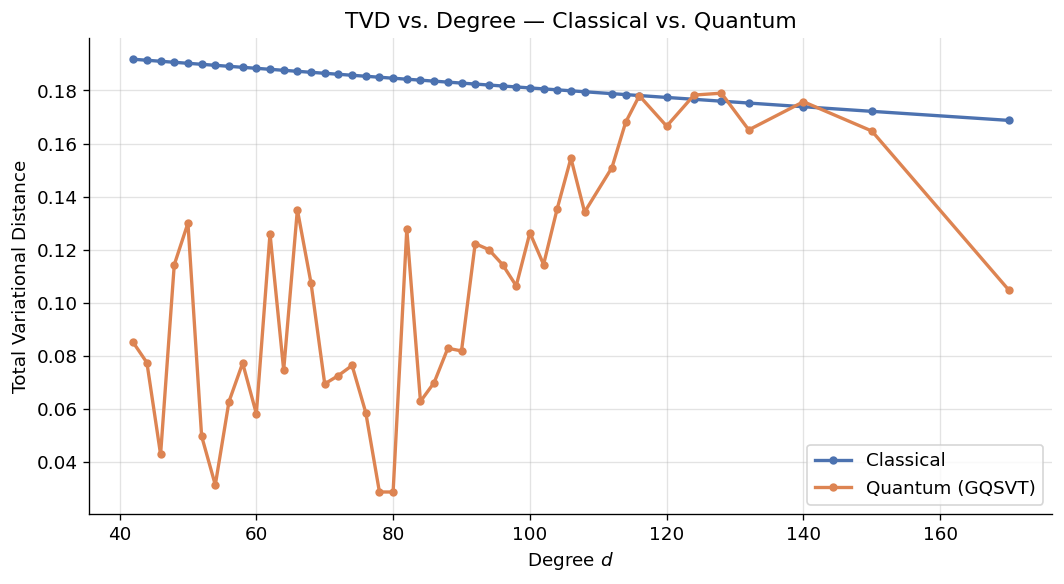

  ε=0.3000  d= 42  |  classical TVD=0.19177   quantum TVD=0.08499


In [28]:
# Sweep ε ∈ [0.001, 0.3] and record TVDs at each unique degree 
epsilon_vals = np.linspace(0.001, 0.3, 200)

deg_plot, tvd_classic, tvd_quantum = [], [], []
seen = set()

for eps in epsilon_vals:
    deg = epsilon_to_degree(eps, spectral_gap)
    if deg in seen:
        continue
    seen.add(deg)

    vd_c = classic_tvd(deg, P, pi)
    vd_q = run_nonreversible(P, eps, degree=deg, shots=100_000)

    deg_plot.append(deg); tvd_classic.append(vd_c); tvd_quantum.append(vd_q)

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(deg_plot, tvd_classic, "o-", color=PALETTE[0], lw=2, ms=4, label="Classical")
    ax.plot(deg_plot, tvd_quantum,  "o-", color=PALETTE[1], lw=2, ms=4, label="Quantum (GQSVT)")
    ax.set_title("TVD vs. Degree — Classical vs. Quantum")
    ax.set_xlabel("Degree $d$"); ax.set_ylabel("Total Variational Distance")
    ax.legend()
    plt.tight_layout(); plt.show()
    print(f"  ε={eps:.4f}  d={deg:3d}  |  classical TVD={vd_c:.5f}   quantum TVD={vd_q:.5f}")

In [29]:
# Summary table: top-3 lowest quantum TVDs 
deg_to_eps = {}
for eps in epsilon_vals:
    d_ = epsilon_to_degree(eps, spectral_gap)
    if d_ not in deg_to_eps:
        deg_to_eps[d_] = eps

top3 = np.argsort(tvd_quantum)[:3]

header = (f"{'Rank':<5} {'ε':<10} {'Q-TVD':<10} {'Q-deg':<8} "
          f"{'C-TVD':<10} {'C-deg (match)'}")
print("Top 3 lowest quantum TVDs")

print(header); print("─" * len(header))

for rank, idx in enumerate(top3, 1):
    q_tvd = tvd_quantum[idx]; q_deg = deg_plot[idx]
    c_tvd = tvd_classic[idx]
    eps_v = deg_to_eps.get(q_deg, float("nan"))

    # Smallest classical degree achieving TVD ≤ q_tvd
    match = next((d_ for d_ in range(2, 20001, 2)
                  if classic_tvd(d_, P, pi) <= q_tvd), None)

    print(f"{rank:<5} {eps_v:<10.4f} {q_tvd:<10.5f} {q_deg:<8} "
          f"{c_tvd:<10.5f} {match if match else '>20000'}")

Top 3 lowest quantum TVDs
Rank  ε          Q-TVD      Q-deg    C-TVD      C-deg (match)
─────────────────────────────────────────────────────────────
1     0.0566     0.02861    80       0.18462    1944
2     0.0611     0.02864    78       0.18499    1944
3     0.1783     0.03128    54       0.18948    1856


---
## 8 · Noise Analysis

Real quantum hardware introduces **depolarising noise**.  We model it with a  
single-qubit error rate $p/10$ and a two-qubit error rate $p$, and sweep $p$  
to study how the TVD degrades.

In [ ]:
def make_noise_model(p):
    """Depolarising noise model: 2-qubit rate p, 1-qubit rate p/10."""
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p/10, 1), ["x", "sx", "rz"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p,    2), ["cx"])
    return nm


p_vals  = np.arange(0, 5.1e-3, 2e-4)
tvd_noise = []

for p in p_vals:
    sim_n = AerSimulator(noise_model=make_noise_model(p))
    tvd_noise.append(run_nonreversible(P, EPSILON, simulator=sim_n, shots=100_000))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p_vals * 1e3, tvd_noise, color=PALETTE[0], lw=2.2, marker="o", ms=4)
ax.axhline(EPSILON, color="crimson", ls="--", lw=1.5, label=f"ε = {EPSILON} (polynomial target)")
ax.set_xlabel("2-qubit depolarising error rate $p$ (×10⁻³)")
ax.set_ylabel("TVD($\\tilde{\\pi}$, $\\pi$)")
ax.set_title("Effect of depolarising noise on TVD")
ax.legend()
plt.tight_layout()
plt.show()